# Kitchener Watermains + Water Main Breaks
## Initial Pre-processing (Anh)

#### Purpose

This notebook focuses on the initial data cleaning and preparation of the Kitchener watermain datasets for Project 3B.

The main goals are to:

- load and inspect the two raw datasets:
  - `Kitchener_watermains.csv`
  - `Kitchener_watermainbreaks.csv`
- understand the structure, data types, and data quality of each dataset
- clean and standardise key fields such as dates, numeric values, text fields, and IDs
- identify useful columns for later analysis and modelling
- check how the two datasets can be linked together using asset IDs and road segment IDs
- create a clean and consistent base dataset for the next stages of the project

In [2]:
#Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Import Kitchener dataset
breaks = pd.read_csv("../data/Kitchener_watermainbreaks.csv")
mains = pd.read_csv("../data/Kitchener_watermains.csv")

#Quick check on features
print("\nBreaks info:")
print(breaks.info())

print("\nMains info:")
print(mains.info())


Breaks info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2994 entries, 0 to 2993
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   OBJECTID                                        2994 non-null   int64  
 1   Wat Break Incident ID                           2994 non-null   int64  
 2   Incident date                                   2994 non-null   object 
 3   Type of Asset Broken                            2994 non-null   object 
 4   Does the road need to be closed?                540 non-null    object 
 5   Does the sidewalk need to be closed?            537 non-null    object 
 6   Estimated Hours for Repair                      538 non-null    object 
 7   Estimated Number of Units Impacted              525 non-null    object 
 8   CW Service Request Number                       25 non-null     float64
 9   Current status of the break

In [4]:
#Next, we check for ratio of missing values in each columns

#Missing ratio for each column in breaks
breaks_missing_ratio = (breaks.isnull().mean() * 100).sort_values(ascending=False)

print("Missing ratio (%) in breaks:")
print(breaks_missing_ratio)

#Missing ratio for each column in mains
mains_missing_ratio = (mains.isnull().mean() * 100).sort_values(ascending=False)

print("-----------------")
print("Missing ratio (%) in mains:")
print(mains_missing_ratio)

Missing ratio (%) in breaks:
Type of Planned Maintenance                       100.000000
List Valves Opened                                 99.933200
List Valves Closed                                 99.899800
Related Asset Depth (m)                            99.498998
CW Service Request Number                          99.164997
List Hydrants Called Back In                       98.797595
List Hydrants Called Out                           98.396794
Depth of Frost (m)                                 97.261189
Date operations was returned to normal service     96.459586
Repair Type                                        91.783567
Estimated Number of Units Impacted                 82.464930
Does the sidewalk need to be closed?               82.064128
Estimated Hours for Repair                         82.030728
Does the road need to be closed?                   81.963928
CW Workorder #                                     39.011356
UPDATE_DATE                                        18.26

In [5]:
#Drop columns with over 80% missing values
#plus some other columns that are not needed for analysis (like "CW Workorder #", "CONSULTANT", etc.)

#Define columns to be dropped
#Breaks
breaks_drop_cols = [
    "Type of Planned Maintenance",
    "List Valves Opened",
    "List Valves Closed",
    "Related Asset Depth (m)",
    "CW Service Request Number",
    "List Hydrants Called Back In",
    "List Hydrants Called Out",
    "Depth of Frost (m)",
    "Date operations was returned to normal service",
    "Repair Type",
    "Estimated Number of Units Impacted",
    "Does the sidewalk need to be closed?",
    "Estimated Hours for Repair",
    "Does the road need to be closed?",
    "CW Workorder #",
    "OBJECTID",
    "GLOBALID",
    "UPDATE_BY",
    "UPDATE_DATE"
]

#Mains
mains_drop_cols = [
    "BRIDGE_DETAILS",
    "LINED_DATE",
    "CONSULTANT",
    "OBJECTID",
    "MAP_LABEL"
]

#Drop columns in the list
breaks_clean = breaks.drop(columns=[col for col in breaks_drop_cols if col in breaks.columns]).copy()
mains_clean = mains.drop(columns=[col for col in mains_drop_cols if col in mains.columns]).copy()

#Quick check
print("Breaks data after dropping columns:", breaks_clean.shape)
print("Mains data after dropping columns:", mains_clean.shape)

Breaks data after dropping columns: (2994, 18)
Mains data after dropping columns: (16163, 22)


In [6]:
#Now we convert the date/time to correct format

#Breaks date columns
breaks_date_cols = [
    "Incident date",
    "Status last updated date"
]

for col in breaks_date_cols:
    if col in breaks_clean.columns:
        breaks_clean[col] = pd.to_datetime(breaks_clean[col], errors="coerce")

#Mains date columns
mains_date_cols = [
    "INSTALLATION_DATE"
]

for col in mains_date_cols:
    if col in mains_clean.columns:
        mains_clean[col] = pd.to_datetime(mains_clean[col], errors="coerce")

#Quick check on cleaned data
print("\nBreaks head:")
print(breaks.head())
print("-----------------")
print("\nMains head:")
print(mains.head())


Breaks head:
   OBJECTID  Wat Break Incident ID          Incident date  \
0         1                   2252   12/1/2017 3:15:00 PM   
1      7874                   1311  3/26/2001 12:00:00 AM   
2      7875                   1325   9/6/2006 12:00:00 AM   
3      7876                   1328  9/11/2006 12:00:00 AM   
4      7877                   1308  1/27/2000 12:00:00 AM   

  Type of Asset Broken Does the road need to be closed?  \
0                 MAIN                 Partially Closed   
1              SERVICE                              NaN   
2              SERVICE                              NaN   
3              SERVICE                              NaN   
4              SERVICE                              NaN   

  Does the sidewalk need to be closed? Estimated Hours for Repair  \
0                                 Open                12-16 hours   
1                                  NaN                        NaN   
2                                  NaN                   

/var/folders/bk/sln2b49n47g24cwmlq18xqhc0000gn/T/ipykernel_41548/3242174556.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  breaks_clean[col] = pd.to_datetime(breaks_clean[col], errors="coerce")
/var/folders/bk/sln2b49n47g24cwmlq18xqhc0000gn/T/ipykernel_41548/3242174556.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  breaks_clean[col] = pd.to_datetime(breaks_clean[col], errors="coerce")
/var/folders/bk/sln2b49n47g24cwmlq18xqhc0000gn/T/ipykernel_41548/3242174556.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mains_clean[col] = pd.to_datetime(mains_clean[col],

In [7]:
#Check for duplicates
print("Duplicate break IDs:", breaks_clean["Wat Break Incident ID"].duplicated().sum())
print("Duplicate main IDs:", mains_clean["WATMAINID"].duplicated().sum())
print("Duplicate road segment IDs in mains:", mains_clean["ROADSEGMENTID"].duplicated().sum())
print("Duplicate related asset IDs in breaks:", breaks_clean["Related Asset ID"].duplicated().sum())

Duplicate break IDs: 0
Duplicate main IDs: 0
Duplicate road segment IDs in mains: 11155
Duplicate related asset IDs in breaks: 1481


So break incident ID and water main id are unique in both datasets. We will use them as uniques identifier when merging.

In [9]:
#Check match rate before merging
asset_match_rate = breaks_clean["Related Asset ID"].isin(mains_clean["WATMAINID"]).mean() * 100
print(f"Asset ID match rate: {asset_match_rate:.2f}%")

matched_breaks = breaks_clean["Related Asset ID"].isin(mains_clean["WATMAINID"]).sum()
unmatched_breaks = (~breaks_clean["Related Asset ID"].isin(mains_clean["WATMAINID"])).sum()

print("Matched break rows:", matched_breaks)
print("Unmatched break rows:", unmatched_breaks)

Asset ID match rate: 81.90%
Matched break rows: 2452
Unmatched break rows: 542


In [10]:
#Filter to main breaks
breaks_main = breaks_clean[breaks_clean["Type of Asset Broken"] == "MAIN"].copy()

#Keep only breaks that match a main asset
breaks_main_matched = breaks_main[
    breaks_main["Related Asset ID"].isin(mains_clean["WATMAINID"])
].copy()

print("MAIN breaks:", breaks_main.shape)
print("Matched MAIN breaks:", breaks_main_matched.shape)

MAIN breaks: (2922, 18)
Matched MAIN breaks: (2451, 18)


In [19]:
#Aggregate break record at pipe level
break_summary = (
    breaks_main_matched
    .groupby("Related Asset ID")
    .agg(
        break_count=("Wat Break Incident ID", "count"),
        first_break_date=("Incident date", "min"),
        last_break_date=("Incident date", "max")
    )
    .reset_index()
    .rename(columns={"Related Asset ID": "WATMAINID"})
)

break_summary["has_break"] = 1

#Quick check
display(break_summary.head())

,WATMAINID,break_count,first_break_date,last_break_date,has_break
0,270,2,1998-11-20,2007-01-21 00:00:00,1
1,290,4,1987-01-01,2013-02-20 00:00:00,1
2,590,1,2012-11-03,2012-11-03 00:00:00,1
3,660,2,2003-02-21,2003-02-22 00:00:00,1
4,670,3,2007-11-29,2020-12-24 23:02:50,1


In [27]:
#Check the number of pipe with and withdown breaks
pipe_df = mains_clean.merge(
    break_summary,
    on="WATMAINID",
    how="left"
)

pipe_df["break_count"] = pipe_df["break_count"].fillna(0).astype(int)
pipe_df["has_break"] = pipe_df["has_break"].fillna(0).astype(int)

print("Pipe-level dataset shape:", pipe_df.shape)
print(pipe_df["has_break"].value_counts())
display(pipe_df.head())

#Quick check
print("Unique pipes with observed break:", break_summary["WATMAINID"].nunique())
print("Total pipes in mains:", mains_clean["WATMAINID"].nunique())

Pipe-level dataset shape: (16163, 26)
has_break
0    14929
1     1234
Name: count, dtype: int64


,WATMAINID,STATUS,PRESSURE_ZONE,ROADSEGMENTID,CATEGORY,PIPE_SIZE,MATERIAL,LINED,LINED_MATERIAL,INSTALLATION_DATE,...,Undersized,Shallow Main,Condition Score,OVERSIZED,CLEANED,Shape__Length,break_count,first_break_date,last_break_date,has_break
0,10080,ACTIVE,KIT 6,5457,TREATED,450,DI,NO,NONE,1979-01-01,...,N,N,8.50,N,N,34.210563,0,NaT,NaT,0
1,76299,ACTIVE,KIT 4,6390,TREATED,300,DI,NO,NONE,1968-07-01,...,N,N,8.50,N,N,0.355118,0,NaT,NaT,0
2,10110,ACTIVE,KIT 6,5393,TREATED,450,DI,NO,NONE,1979-01-01,...,N,N,6.10,N,Y,67.852910,1,2013-12-16,2013-12-16,1
3,82566,ACTIVE,KIT 6,5393,TREATED,450,DI,NO,NONE,1979-01-01,...,N,N,4.58,N,Y,7.039328,1,2013-12-16,2013-12-16,1
4,82568,ACTIVE,KIT 6,5394,TREATED,450,DI,NO,NONE,1979-01-01,...,N,N,8.50,N,Y,14.956131,0,NaT,NaT,0


Unique pipes with observed break: 1234
Total pipes in mains: 16163


From this ratio, we see that data is imbalanced.

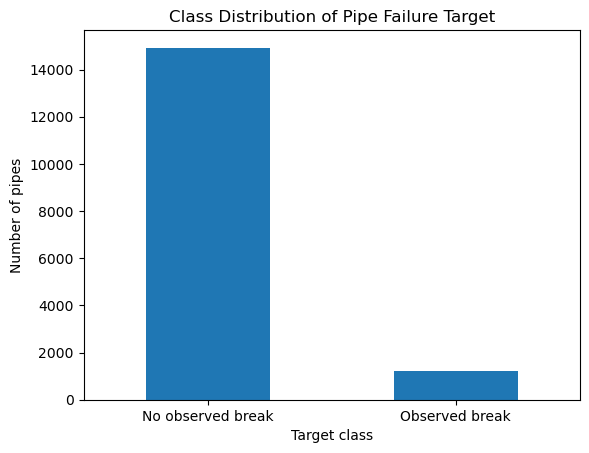

In [35]:
#Explore class distribution
class_counts = pipe_df["has_break"].value_counts().sort_index()
class_pct = (pipe_df["has_break"].value_counts(normalize=True).sort_index() * 100).round(2)

#Visualise class imbalance
plt.figure()
class_counts.plot(kind="bar")
plt.xticks([0, 1], ["No observed break", "Observed break"], rotation=0)
plt.ylabel("Number of pipes")
plt.xlabel("Target class")
plt.title("Class Distribution of Pipe Failure Target")
plt.show()